# Imports

In [1]:
import os
import sys

In [2]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [3]:
parent_dir

'/localhome/home/zgdz996/frank2d'

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [5]:
# frank2d
from frank2d import Frank2D
from frank2d.geometry import Geometry
from frank2d.plot import Plot
from frank2d.posterior_optimization import *
from frank2d.constants import rad_to_arcsec, deg_to_rad
from frank2d.posterior_optimization import MAPEstimator

In [6]:
# Huang 2018 
AS209 = {'inc': 34.97, 'pa': 85.76, 'dra':1.9e-3, 'ddec':-2.5e-3, 'rout': 1.2*2, 'disk_name': 'AS209'}
IMLup = {'inc': 47.5, 'pa': 144.5, 'dra':-1.5e-3, 'ddec':1e-3, 'rout': 1.71*2, 'disk_name': 'IMLup'}
Elias27 = {'inc': 56.2, 'pa': 118.8, 'dra':-5e-3, 'ddec':-8e-3, 'rout': 1.88*2, 'disk_name': 'Elias27'}
Elias24 = {'inc': 29, 'pa': 45.7, 'dra':110.8e-3, 'ddec':-386.8e-3, 'rout': 1.03*2, 'disk_name': 'Elias24'}
HD163296 = {'inc':46.7, 'pa':133.33, 'dra':-2.8e-3, 'ddec':7.7e-3, 'rout':1.7*2, 'disk_name': 'HD163296' }
HD143006 = {'inc': 18.6, 'pa': 169, 'dra':-5.9e-3, 'ddec':21.7e-3, 'rout': 0.518*3, 'disk_name': 'HD143006'}

In [7]:
data =  AS209

In [8]:

dir = "./../../data/"
disk_name = data['disk_name']
data_file = dir +"uvtable_" + disk_name + "_continuum.npz"

inc = data['inc']
pa = data['pa']
dra = data['dra']
ddec = data['ddec']
rout = data['rout']

# Frank Parameters
N = 1000

# Load data
file = np.load(data_file)
u, v, Re, Im, Weights = file['u'], file['v'], file['Re'], file['Im'], file['w']
Vis = Re + Im*1j
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights }

geom = Geometry(inc, pa, dra, ddec)

### UV coverage

In [9]:
# plot 3D of the uv coverage
"""
plt.figure(figsize=(8, 6))
scatter = plt.scatter(u, v, c= np.ones_like(Vis), cmap='magma', marker='o', alpha = 0.5)
plt.colorbar(scatter)

plt.xlabel(r'u [$\lambda$]')
plt.ylabel(r'v [$\lambda$]')
plt.title('UV-coverage of Elias27 observations')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
"""

"\nplt.figure(figsize=(8, 6))\nscatter = plt.scatter(u, v, c= np.ones_like(Vis), cmap='magma', marker='o', alpha = 0.5)\nplt.colorbar(scatter)\n\nplt.xlabel(r'u [$\\lambda$]')\nplt.ylabel(r'v [$\\lambda$]')\nplt.title('UV-coverage of Elias27 observations')\nplt.grid(True, linestyle='--', alpha=0.5)\nplt.show()\n"

### Analitic functions

In [10]:
import numpy as np
from scipy.special import j0, j1, jn

In [11]:
def synthetic_uvtable_crescent(u, v,
                               sigma_core=0.04,
                               R_rings=[0.4, 0.6, 0.8],
                               width_rings=[0.05, 0.02, 0.05],
                               amp_core=0.1,
                               amp_rings=[0.05, 0.04, 0.03],
                               m_modes=[1, 0, 0],       # asymmetry order for each ring
                               theta0=[np.pi, 0, 0],   # phase angle of each asymmetry component
                               amp_asym=[0.5, 0.3, 0.3],  # relative strength of asymmetry
                               rad_to_arcsec=206265.0,
                               weights=None):
    """
    Generate a synthetic UV table using asymmetric Gaussian-width rings (Fourier-domain model).
    Asymmetries are introduced using low-order azimuthal modes (m-modes).
    """
    baseline = np.sqrt(u**2 + v**2)
    phi_uv = np.arctan2(v, u)  # uv-plane azimuth angle

    # Central Gaussian core (symmetric)
    V_core = amp_core * np.exp(-2 * (np.pi * (sigma_core / rad_to_arcsec) * baseline)**2)

    # Ring components with azimuthal modulation
    V_rings = np.zeros_like(baseline, dtype=complex)

    for A, R, w, m, th0, Aasym in zip(amp_rings, R_rings, width_rings, m_modes, theta0, amp_asym):
        arg = 2 * np.pi * (R / rad_to_arcsec) * baseline
        blur = np.exp(-2 * (np.pi * (w / rad_to_arcsec) * baseline)**2)

        # Axisymmetric ring contribution (m = 0)
        V0 = A * j0(arg) * blur

        # Asymmetric contribution (m-mode modulation)
        Vm = Aasym * A * jn(m, arg) * blur * np.exp(1j * m * (phi_uv - th0))

        V_rings += V0 + Vm

    # Combine core + rings
    vis = V_core + V_rings

    # Default weights = uniform (if none provided)
    if weights is None:
        weights = np.ones_like(u)

    # Determine if noise should be real or complex
    dim0 = 2 if np.iscomplexobj(vis) else 1

    # Add Gaussian noise scaled by weights
    noise = np.random.standard_normal((dim0,) + vis.shape)
    noise *= weights ** -0.5

    vis_noisy = vis + noise[0]
    if np.iscomplexobj(vis):
        vis_noisy += 1j * noise[1]

    # Return UV table dictionary
    uvtable = {
        'u': u,
        'v': v,
        'vis': vis,
        'weights': weights
    }

    return uvtable


In [12]:
def synthetic_uvtable_gaussian_blob(u, v,
                                    sigma_core=0.04,
                                    R_rings=[0.4, 0.6, 0.8],
                                    width_rings=[0.04, 0.02, 0.05],
                                    width_blobs=[0.03, 0.03, 0.03],
                                    amp_core=0.1,
                                    amp_rings=[0.09, 0.07, 0.05],
                                    m_modes=[1, 0, 0],
                                    theta0=[np.pi, 0, 0],
                                    amp_asym=[0.05, 0, 0],
                                    rad_to_arcsec=206265.0,
                                    weights=None):
    """
    Generate a synthetic UV table containing symmetric rings plus localized
    Gaussian 'blob' features.

    Asymmetries are introduced by adding a shifted 2D Gaussian component,
    modeled in the UV plane using the Fourier Shift Theorem.
    """
    baseline = np.sqrt(u**2 + v**2)
    
    # Central Gaussian core
    V_core = amp_core * np.exp(-2 * (np.pi * (sigma_core / rad_to_arcsec) * baseline)**2)

    # Rings + Gaussian blobs
    V_rings_and_blobs = np.zeros_like(baseline, dtype=complex)

    # Iterate through the properties of each ring/blob component
    for A, R, w, w_blob, m, th0, Aasym in zip(amp_rings, R_rings,
                                              width_rings, width_blobs,
                                              m_modes, theta0, amp_asym):

        # Symmetric ring component (m = 0)
        arg = 2 * np.pi * (R / rad_to_arcsec) * baseline
        blur = np.exp(-2 * (np.pi * (w / rad_to_arcsec) * baseline)**2)
        V_ring = A * j0(arg) * blur

        V_rings_and_blobs += V_ring

        # Localized Gaussian blob (only if m != 0)
        if m != 0 and Aasym > 0:
            # Blob amplitude and width
            A_blob = Aasym * A
            R_blob = R
            sigma_blob = w_blob
            sigma_blob_rad = sigma_blob / rad_to_arcsec

            # Fourier transform of a centered Gaussian
            V_blob_centered = A_blob * np.exp(-2 * (np.pi * sigma_blob_rad * baseline)**2)

            # Blob center position in radians
            x0_rad = (R_blob / rad_to_arcsec) * np.cos(th0)
            y0_rad = (R_blob / rad_to_arcsec) * np.sin(th0)

            # Fourier shift: exp(-2π i (u·x0 + v·y0))
            phase_shift = np.exp(-2j * np.pi * (u * x0_rad + v * y0_rad))

            # Shifted blob visibility
            V_blob = V_blob_centered * phase_shift

            V_rings_and_blobs += V_blob

    # Total visibilities
    vis = V_core + V_rings_and_blobs
    vis = np.array(vis)

    # Default weights = uniform
    if weights is None:
        weights = np.ones_like(u)

    # Determine if noise should be real or complex
    dim0 = 2 if np.iscomplexobj(vis) else 1

    np.random.seed(93572)

    # Add Gaussian noise scaled by weights
    noise = np.random.standard_normal((dim0,) + vis.shape)
    noise *= weights ** -0.5

    print(noise)

    vis_noisy = vis + noise[0]
    if np.iscomplexobj(vis):
        vis_noisy += 1j * noise[1]

    # Return UV table dict
    uvtable = {
        'u': u,
        'v': v,
        'vis': vis,
        'weights': weights
    }

    return uvtable


In [13]:
def create_disk_image_blob_jy_per_pixel(
    N=500,                         # Image size (N x N pixels)
    pixel_scale_arcsec=0.01,       # Pixel scale (0.01 arcsec = 10 mas)
    sigma_core=0.04,               # Gaussian core width (arcsec)
    R_rings=[0.4, 0.6, 0.8],       # Radii of the rings/blobs (arcsec)
    width_rings=[0.05, 0.02, 0.05], # Gaussian width of the rings (arcsec)
    width_blobs=[0.03, 0.03, 0.03], # Width of the localized blobs (arcsec)
    amp_core=0.1,                  # Core amplitude (Jy/pixel)
    amp_rings=[0.05, 0.04, 0.03],  # Rings amplitude (Jy/pixel)
    m_modes=[1, 0, 0],             # Asymmetry mode (1 -> blob, 0 -> ring)
    theta0=[np.pi, 0, 0],     # Blob position angle (radians)
    amp_asym=[0.9, 0, 0]           # Asymmetry/blob amplitude (fraction of amp_rings)
):
    """
    Creates a synthetic disk image directly in Jy/pixel by summing
    Gaussian and annular components in the image plane.
    """
    
    # 1. Prepare coordinate grid and radii
    
    # Pixel coordinates (in arcsec, with center at (0, 0))
    x_arcsec = (np.arange(N) - N / 2) * pixel_scale_arcsec
    y_arcsec = (np.arange(N) - N / 2) * pixel_scale_arcsec
    
    # Create the 2D grid of coordinates and radii
    X, Y = np.meshgrid(x_arcsec, y_arcsec)
    R_image = np.sqrt(X**2 + Y**2)
    Phi_image = np.arctan2(Y, X) # Polar angle of each pixel
    
    # Initialize the total image in Jy/pixel
    I_disk_jy_per_pixel = np.zeros((N, N))
    
    # 2. Add the Central Gaussian Core
    
    # 2D Gaussian Formula: I(r) = A * exp(- (r^2 / (2 * sigma^2)))
    # Note: Your original code uses exp(-2 * (pi * sigma * baseline)^2), 
    # which is the FT of a Gaussian. In the image plane, we use the standard form:
    sigma_image = sigma_core / np.sqrt(2 * np.log(2)) # Approximation FWHM -> sigma (Commented out line, original uses sigma_core directly)
    
    I_core = amp_core * np.exp(-0.5 * (R_image / sigma_core)**2)
    I_disk_jy_per_pixel += I_core
    
    # 3. Add Rings and Blobs
    
    # Iterate over the properties of each component
    for A, R, w, w_blob, m, th0, Aasym in zip(amp_rings, R_rings,
                                              width_rings, width_blobs,
                                              m_modes, theta0, amp_asym):
        
        # Symmetric Ring (Gaussian centered at radius R)
        # Formula: I(r) = A * exp(-(r - R)^2 / (2 * w^2))
        I_ring = A * np.exp(-0.5 * ((R_image - R) / w)**2)
        I_disk_jy_per_pixel += I_ring
        
        # Asymmetric Blobs (Displaced Gaussian)
        if m != 0 and Aasym > 0:
            
            # Blob center position (in arcsec)
            x0 = R * np.cos(th0)
            y0 = R * np.sin(th0)
            
            # Coordinate offset
            X_blob = X - x0
            Y_blob = Y - y0
            R_blob_sq = X_blob**2 + Y_blob**2
            
            # Blob amplitude (fraction of the ring)
            A_blob = Aasym * A
            
            # Blob Gaussian (centered at (x0, y0))
            I_blob = A_blob * np.exp(-0.5 * (R_blob_sq / w_blob**2))
            
            I_disk_jy_per_pixel += I_blob
            
    return I_disk_jy_per_pixel

In [14]:
def create_disk_image_jy_per_pixel_crescent(
    N=512,                           # Image size (N x N pixels)
    pixel_scale_arcsec=0.01,         # Pixel scale (e.g., 0.01 arcsec = 10 mas)
    sigma_core=0.04,                 # Width of the central Gaussian core (arcsec)
    R_rings=[0.4, 0.6, 0.8],         # Radii of the rings/components (arcsec)
    width_rings=[0.05, 0.02, 0.05],  # Gaussian width of the rings (arcsec)
    amp_core=0.1,                    # Amplitude of the core (Jy/pixel)
    amp_rings=[0.1, 0.04, 0.03],     # Amplitude of the rings (Jy/pixel)
    m_modes=[1, 0, 0],               # Asymmetry mode (1 -> crescent, 0 -> symmetric ring)
    theta0=[np.pi, 0, 0],          # Angle of the crescent maximum (radians)
    amp_asym=[0.5, 0, 0]             # Asymmetry factor (fraction of amp_rings)
):
    
    # 1. Setup Coordinate Grid
    x_arcsec = (np.arange(N) - N / 2) * pixel_scale_arcsec
    y_arcsec = (np.arange(N) - N / 2) * pixel_scale_arcsec
    
    X, Y = np.meshgrid(x_arcsec, y_arcsec)
    R_image = np.sqrt(X**2 + Y**2)
    Phi_image = np.arctan2(Y, X)
    
    I_disk_jy_per_pixel = np.zeros((N, N))
    
    # 2. Add the Central Gaussian Core
    I_core = amp_core * np.exp(-0.5 * (R_image / sigma_core)**2)
    I_disk_jy_per_pixel += I_core
    
    # 3. Add Rings and Crescents
    for A, R, w, m, th0, Aasym in zip(amp_rings, R_rings,
                                      width_rings, m_modes, theta0, amp_asym):
        
        radial_profile = np.exp(-0.5 * ((R_image - R) / w)**2)
        
        if m != 0 and Aasym > 0:
            angular_modulation = (1 + Aasym * np.cos(m * (Phi_image - th0)))
            I_component = A * radial_profile * angular_modulation
            
        else:
            I_component = A * radial_profile
            
        I_disk_jy_per_pixel += I_component
            
    return I_disk_jy_per_pixel

#### synthetic_uvtable_gaussian_blob

In [15]:
frank2d0 = Frank2D(N, rout)

In [16]:
frank2d0.process_vis(uvtable)

===>  Setting gridded data...


In [17]:
u, v = frank2d0.gridded_data['u'], frank2d0.gridded_data['v']
weights = frank2d0.gridded_data['weights']

In [24]:
uvtable_synthetic_full = synthetic_uvtable_crescent(u, v, weights= weights)

In [25]:
vis_syn_full =  uvtable_synthetic_full['vis'].reshape(N, N)
weights_syn_full = uvtable_synthetic_full['weights'].reshape(N, N)
u_syn_full = uvtable_synthetic_full['u'].reshape(N, N)
v_syn_full = uvtable_synthetic_full['v'].reshape(N, N)


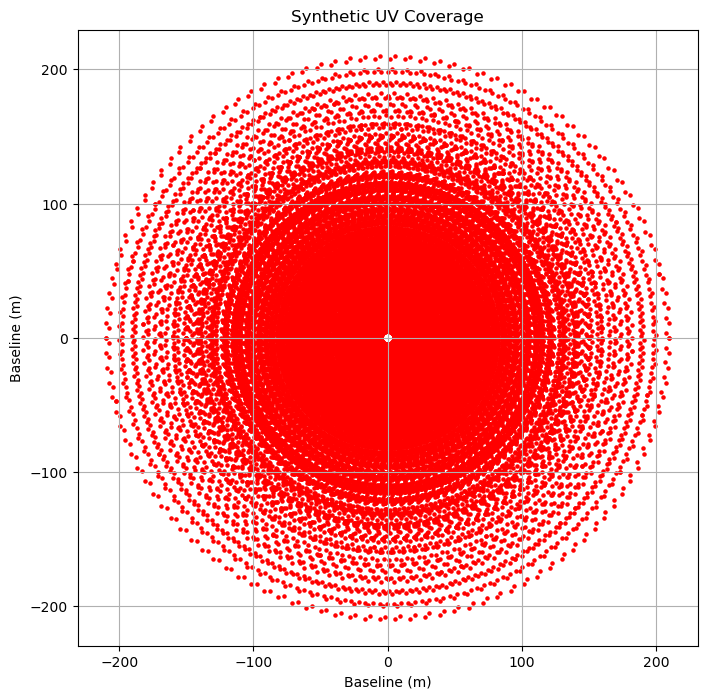

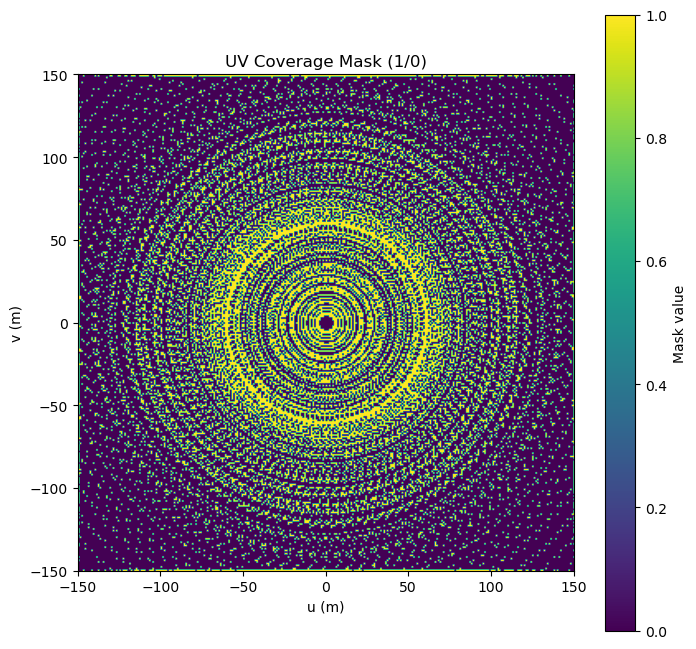

In [210]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1) Generar antenas en un arreglo sintético
# -----------------------------
def generate_antennas(N=10, radius=10):
    """
    Genera N antenas distribuidas en forma de espiral.
    """
    angles = np.linspace(0, 4*np.pi, N)
    r = np.linspace(0, radius, N)
    x = r * np.cos(angles)
    y = r * np.sin(angles)
    return np.vstack((x, y)).T  # shape (N,2)


# -----------------------------
# 2) Obtener baselines entre todas las antenas
# -----------------------------
def get_baselines(antennas):
    N = antennas.shape[0]
    baselines = []
    for i in range(N):
        for j in range(i+1, N):
            dx = antennas[j,0] - antennas[i,0]
            dy = antennas[j,1] - antennas[i,1]
            baselines.append([dx, dy])
            baselines.append([-dx, -dy])  # conjugado UV
    return np.array(baselines)


# -----------------------------
# 3) Agregar rotación terrestre
# -----------------------------
def earth_rotation(baselines, n_times=10):
    """
    Rota los baselines a través del tiempo (simula rotación terrestre)
    """
    uv = []
    angles = np.linspace(0, 2*np.pi, n_times)
    for theta in angles:
        R = np.array([[np.cos(theta), -np.sin(theta)],
                      [np.sin(theta),  np.cos(theta)]])
        uv_t = baselines @ R.T
        uv.append(uv_t)
    return np.vstack(uv)


# -----------------------------
# 4) Crear máscara UV en una grilla
# -----------------------------
def uv_mask(u_samples, v_samples, grid_size=301, max_uv=150):
    """
    Devuelve una máscara en una grilla cuadrada (grid_size x grid_size)
    """
    grid = np.linspace(-max_uv, max_uv, grid_size)
    u_grid, v_grid = np.meshgrid(grid, grid)
    
    mask = np.zeros_like(u_grid, dtype=int)

    ug = u_grid.ravel()
    vg = v_grid.ravel()

    for u, v in zip(u_samples, v_samples):
        idx = np.argmin((ug - u)**2 + (vg - v)**2)
        i, j = np.unravel_index(idx, u_grid.shape)
        mask[i, j] = 1

    return u_grid, v_grid, mask


# -----------------------------
# 5) Ejecutar todo el pipeline
# -----------------------------
antennas = generate_antennas(N=25, radius=120)
baselines = get_baselines(antennas)
uv_points = earth_rotation(baselines, n_times=60)

u_samples, v_samples = uv_points[:,0], uv_points[:,1]

u_grid, v_grid, mask = uv_mask(u_samples, v_samples)

# -----------------------------
# 6) Graficar
# -----------------------------
plt.figure(figsize=(8,8))
plt.scatter(u_samples, v_samples, s=5, color="red")
plt.xlabel("Baseline (m)")
plt.ylabel("Baseline (m)")
plt.title("Synthetic UV Coverage")
plt.grid(True)
plt.axis("equal")
plt.show()

plt.figure(figsize=(8,8))
plt.imshow(mask, extent=[-150,150,-150,150], origin="lower")
plt.title("UV Coverage Mask (1/0)")
plt.colorbar(label="Mask value")
plt.xlabel("u (m)")
plt.ylabel("v (m)")
plt.show()

In [199]:
du = frank2d0.u[1] - frank2d0.u[0]
u_max = uvtable['u'].max()
Nu =  2/du*u_max

dv = frank2d0.v[1] - frank2d0.v[0]
v_max = uvtable['v'].max()
Nv =  2/dv*v_max

print(Nu, Nv)

317.0265853383627 377.97948675062776


In [200]:
dx = frank2d0.dx/rad_to_arcsec
dy = frank2d0.dy/rad_to_arcsec
pixel_area_in_sr = dx * dy
I_syn_full_Jy_per_sr = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(V_covered_2d))).real / pixel_area_in_sr
I_syn_full_Jy_per_pixel = I_syn_full_Jy_per_sr * pixel_area_in_sr

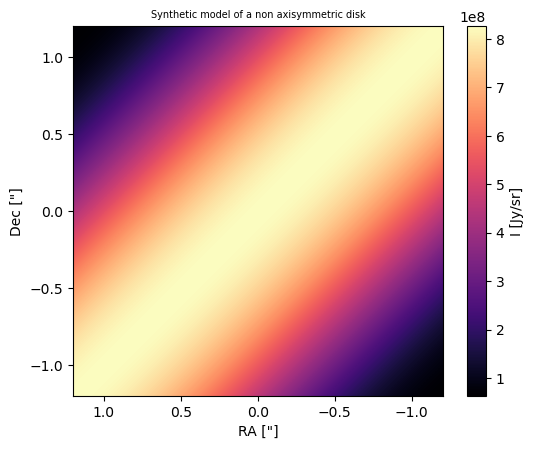

In [201]:
import matplotlib.colors as colors
norm = colors.PowerNorm(gamma = 1)
plt.imshow(
            I_syn_full_Jy_per_sr, 
            extent=[frank2d0.Rmax, -frank2d0.Rmax, -frank2d0.Rmax, frank2d0.Rmax],
            norm=norm, 
            cmap = 'magma'
            )

plt.gca().invert_yaxis()
plt.xlim(rout/2, -rout/2)
plt.ylim(-rout/2, rout/2)
plt.title('Synthetic model of a non axisymmetric disk', size =7)
plt.xlabel('RA ["]')
plt.ylabel('Dec ["]')
plt.colorbar(label='I [Jy/sr]')

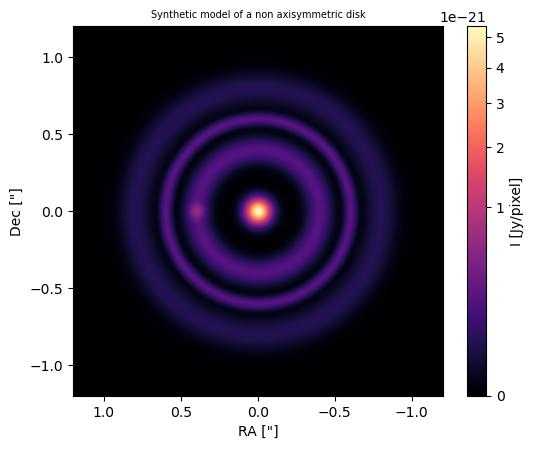

In [34]:
import matplotlib.colors as colors

norm = colors.PowerNorm(gamma = 0.4, vmax = I_syn_full_Jy_per_pixel.max())

plt.imshow(
            I_syn_full_Jy_per_pixel, 
            extent=[frank2d0.Rmax, -frank2d0.Rmax, -frank2d0.Rmax, frank2d0.Rmax],
            norm=norm, 
            cmap = 'magma'
            )

plt.gca().invert_yaxis()
plt.xlim(rout/2, -rout/2)
plt.ylim(-rout/2, rout/2)
plt.title('Synthetic model of a non axisymmetric disk', size =7)
plt.xlabel('RA ["]')
plt.ylabel('Dec ["]')
plt.colorbar(label='I [Jy/pixel]')

#### create_disk_image_jy_per_pixel

Imagen creada con dimensiones (600, 600)
Área sólida del píxel (sigma): 2.3504e-15 sr
Intensidad máxima en Jy/píxel: 2.5000e-04 Jy/píxel
Intensidad máxima en Jy/sr: 1.0636e+11 Jy/sr


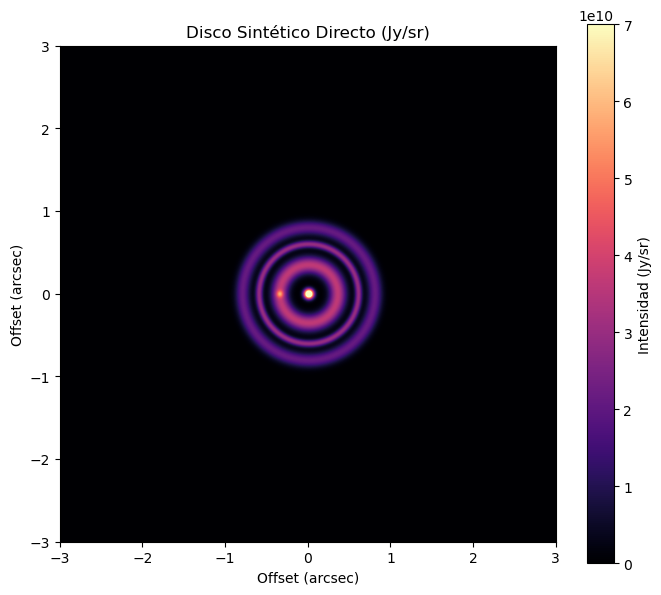

In [61]:
N = 600
dx = 0.01  # arcsec
rad_to_arcsec = 3600 * 180 / np.pi
dxy = dx/rad_to_arcsec

# Parámetros Ajustados
amp_core_ajustado = 0.00025
amp_rings_ajustado = [0.000086, 0.000070, 0.000050] 
amp_asym_ajustado = [0.6, 0, 0]

image_jy_per_pixel = create_disk_image_blob_jy_per_pixel(
    N=N,                         # Image size (N x N pixels)
    pixel_scale_arcsec=dx,       # Pixel scale (0.01 arcsec = 10 mas)
    sigma_core=0.04,               # Gaussian core width (arcsec)
    R_rings=[0.35, 0.6, 0.8],       # Radii of the rings/blobs (arcsec)
    width_rings=[0.07, 0.03, 0.06], # Gaussian width of the rings (arcsec)
    width_blobs=[0.03, 0.03, 0.03], # Width of the localized blobs (arcsec)
    amp_core=amp_core_ajustado,    # Core amplitude (Jy/pixel)
    amp_rings=amp_rings_ajustado,  # Rings amplitude (Jy/pixel)
    amp_asym=amp_asym_ajustado,
    theta0=[np.pi, 0, 0],
    m_modes=[1, 0, 0])

# Cálculo del área sólida (en sr)
sigma_sr =  (dx/rad_to_arcsec)**2 # Renombrado a sigma_sr para evitar confusión

# Conversión a Jy/sr
image_jy_per_sr = image_jy_per_pixel / sigma_sr

print(f"Imagen creada con dimensiones {image_jy_per_pixel.shape}")
print(f"Área sólida del píxel (sigma): {sigma_sr:.4e} sr")
print(f"Intensidad máxima en Jy/píxel: {image_jy_per_pixel.max():.4e} Jy/píxel")
print(f"Intensidad máxima en Jy/sr: {image_jy_per_sr.max():.4e} Jy/sr")

# Mostrar la imagen en Jy/sr
plt.figure(figsize=(8, 7))
# El valor vmax se establece en el límite deseado (1e11 Jy/sr)
plt.imshow(image_jy_per_sr, extent=[-3, 3, -3, 3], cmap='magma', vmax = 7e10) 
plt.colorbar(label='Intensidad (Jy/sr)')
plt.title('Disco Sintético Directo (Jy/sr)')
plt.xlabel('Offset (arcsec)')
plt.ylabel('Offset (arcsec)')
plt.show()

Intensidad máxima en Jy/sr: 9.9768e+10 Jy/sr

--- Verificación de Intensidades Relativas (en Jy/píxel) ---
Intensidad Máxima del Centro (S_core): 0.000235 Jy/píxel
Intensidad Máxima del Creciente (S_crescent, max): 0.000136 Jy/píxel
Intensidad Mínima Visible del Anillo 1 (S_min, anillo): 0.000058 Jy/píxel

Requerimiento 1 (I_max <= 1e11 Jy/sr): True
Requerimiento 2 (I_base < I_crescent < I_centro): True
Requerimiento 3 (Anillo completo visible): True


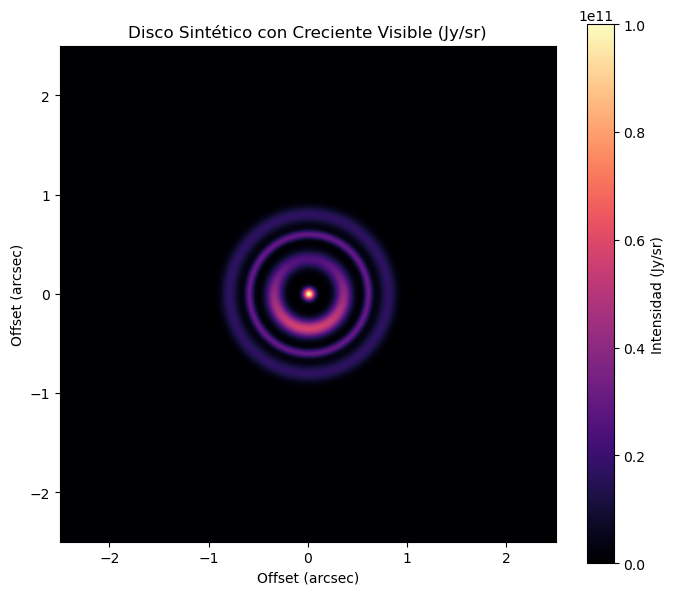

In [45]:
N = 500
dx = 0.01  # arcsec
rad_to_arcsec = 3600 * 180 / np.pi

# --- Parámetros Ajustados ---
amp_core_ajustado = 0.0002345 
amp_rings_ajustado = [0.000097, 0.000070, 0.000040] 
amp_asym_ajustado = [0.4, 0, 0]

image_jy_per_pixel_crescent = create_disk_image_jy_per_pixel_crescent(
    N=N,
    amp_core=amp_core_ajustado,
    pixel_scale_arcsec=dx,
    R_rings=[0.35, 0.6, 0.8],
    amp_rings=amp_rings_ajustado,
    width_rings=[0.06, 0.03, 0.06],
    m_modes=[1, 0, 0],
    theta0=[np.pi/2, 0, 0],
    amp_asym=amp_asym_ajustado
)

# Cálculo del área sólida (en sr)
sigma_sr =  (dx/rad_to_arcsec)**2 
image_jy_per_sr = image_jy_per_pixel_crescent / sigma_sr

print(f"Intensidad máxima en Jy/sr: {image_jy_per_sr.max():.4e} Jy/sr")

# Verificación de las condiciones de Intensidad
I_max_centro_jp = amp_core_ajustado
I_max_anillo1_jp_min = amp_rings_ajustado[0] * (1 - amp_asym_ajustado[0]) # I_min del anillo 1 (no debe ser 0)
I_max_anillo1_jp_base = amp_rings_ajustado[0] # Base simétrica, para la condición 2 usamos este valor.
I_max_crescent_jp = amp_rings_ajustado[0] * (1 + amp_asym_ajustado[0])

print("\n--- Verificación de Intensidades Relativas (en Jy/píxel) ---")
print(f"Intensidad Máxima del Centro (S_core): {I_max_centro_jp:.6f} Jy/píxel")
print(f"Intensidad Máxima del Creciente (S_crescent, max): {I_max_crescent_jp:.6f} Jy/píxel")
print(f"Intensidad Mínima Visible del Anillo 1 (S_min, anillo): {I_max_anillo1_jp_min:.6f} Jy/píxel")


condicion_1 = image_jy_per_sr.max() <= 1.05e11 # I_max <= 1e11 Jy/sr
condicion_2 = (I_max_anillo1_jp_base < I_max_crescent_jp) and (I_max_crescent_jp < I_max_centro_jp) # I_base < I_crescent < I_centro
condicion_3 = I_max_anillo1_jp_min > 0 # Anillo completo visible

print(f"\nRequerimiento 1 (I_max <= 1e11 Jy/sr): {condicion_1}")
print(f"Requerimiento 2 (I_base < I_crescent < I_centro): {condicion_2}")
print(f"Requerimiento 3 (Anillo completo visible): {condicion_3}")

# Mostrar la imagen en Jy/sr
plt.figure(figsize=(8, 7))
plt.imshow(image_jy_per_sr, extent=[-2.5, 2.5, -2.5, 2.5], cmap='magma', vmax = 1e11) 
plt.colorbar(label='Intensidad (Jy/sr)')
plt.title('Disco Sintético con Creciente Visible (Jy/sr)')
plt.xlabel('Offset (arcsec)')
plt.ylabel('Offset (arcsec)')
plt.show()

## AS209 UV-coverage

In [144]:
uvtable_synthetic = synthetic_uvtable_gaussian_blob(uvtable['u'], uvtable['v'], weights=uvtable['weights'])

[[ 0.01353533 -0.01008821  0.04930858 ...  0.04674869  0.02734788
  -0.05942386]
 [-0.02098779 -0.01096698 -0.02484401 ...  0.0110301  -0.02325816
  -0.02881985]]


In [145]:
u_syn, v_syn = uvtable_synthetic['u'], uvtable_synthetic['v']
vis_syn = uvtable_synthetic['vis']
weights_syn = uvtable_synthetic['weights']

In [130]:
#np.savez_compressed("uvtable_nonsym_disc_blob_noisy.npz", **uvtable_synthetic)

In [122]:
N = 300
rout = 1*2
frank2d = Frank2D(N, rout, geom)

In [123]:
frank2d.process_vis(uvtable_synthetic)

===>  Setting gridded data...


In [124]:
uvtable_synthetic_gridded = frank2d.gridded_data

In [125]:
u_syn = uvtable_synthetic_gridded['u'].reshape(N, N)
v_syn = uvtable_synthetic_gridded['v'].reshape(N, N)
vis_syn = uvtable_synthetic_gridded['vis'].reshape(N, N)
weights_syn = uvtable_synthetic_gridded['weights'].reshape(N, N)

Text(0, 0.5, 'v [λ]')

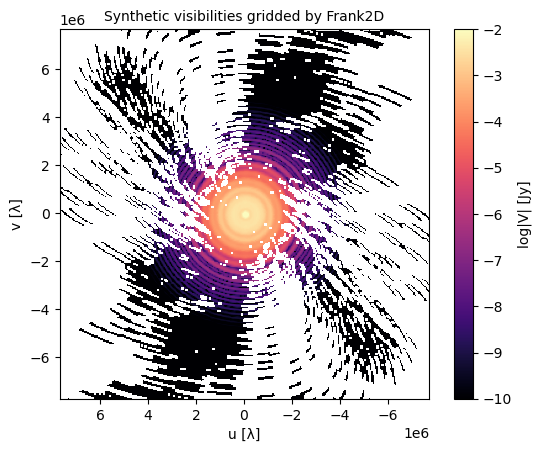

In [126]:
plt.imshow(np.log(np.abs(vis_syn)),
             extent=[u_syn.max(), u_syn.min(), v_syn.min(), v_syn.max()],
             cmap = "magma", 
             vmin=-10, vmax=-2)
plt.colorbar(label='log|V| [Jy]')
plt.title('Synthetic visibilities gridded by Frank2D', size=10)
plt.xlabel('u [λ]')
plt.ylabel('v [λ]')

In [132]:
params_1 = {'m' : -2, 'c' : 1e8, 'l' : 7e4}
params_2 = {'m' : -1.8, 'c' : 1e9, 'l' : 7e4}
params_3 = {'m' : -1.5, 'c' : 1e9, 'l' : 7e4}
best = {'m': -2.0109174914721892, 'c': 10930405059.44571, 'l': 2633846.3020098973}

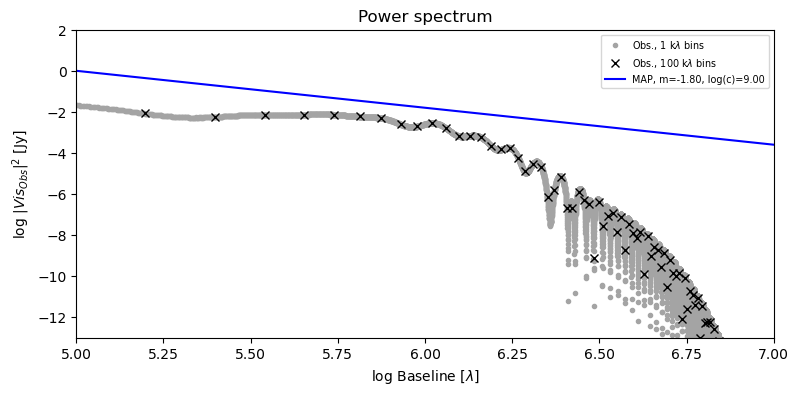

In [146]:
# Plot visibilities gridded.
from frank.utilities import UVDataBinner       
bin_widths=[1e3, 1e5]

u, v = u_syn.flatten(), v_syn.flatten()
Vis = vis_syn.flatten()
Weights = weights_syn.flatten()

baselines = np.hypot(u, v)
binned_vis = UVDataBinner(baselines, Vis, Weights, bin_widths[0])
logx = np.log10(binned_vis.uv)
logy = np.log10(np.abs(binned_vis.V)**2)

binned_vis2 = UVDataBinner(baselines, Vis, Weights, bin_widths[1])
logx2 = np.log10(binned_vis2.uv)
logy2 = np.log10(np.abs(binned_vis2.V)**2)

def linear_power_spectrum(logx, m, c):
    return m*logx + np.log10(c)


lgx = np.log10(np.geomspace(np.sort(baselines)[1], baselines.max(), 1000))

lgy1 = linear_power_spectrum(lgx, params_1['m'], params_1['c'])
lgy2 = linear_power_spectrum(lgx, params_2['m'], params_2['c'])
lgy3 = linear_power_spectrum(lgx, params_3['m'], params_3['c'])
#lgy_best = linear_power_spectrum(lgx, best['m'], best['c'])

cs, ms = ['#a4a4a4', 'k'], ['.', 'x']

plt.figure(figsize=(9, 4))
plt.plot(logx, logy, c=cs[0], marker=ms[0], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))
plt.plot(logx2, logy2, c=cs[1], marker=ms[1], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))

#plt.plot(lgx, lgy1, ls='-', color= 'r', label='MAP, m={:.2f}, log(c)={:.2f}'.format(params_1['m'], np.log10(params_1['c'])))
plt.plot(lgx, lgy2, ls='-', color= 'blue', label='MAP, m={:.2f}, log(c)={:.2f}'.format(params_2['m'], np.log10(params_2['c'])))
#plt.plot(lgx, lgy3, ls='-', color= 'green', label='MAP, m={:.2f}, log(c)={:.2f}'.format(params_3['m'], np.log10(params_3['c'])))
#plt.plot(lgx, lgy_best, ls='--', color= 'orange', label='Best fit, m={:.2f}, log(c)={:.2f}'.format(best['m'], np.log10(best['c'])))

plt.xlabel(r'log Baseline [$\lambda$]', size = 10)
plt.ylabel(r'log $|Vis_{Obs}|^{2}$ [Jy]', size = 10)
plt.legend(loc = 'best', fontsize = 'x-small')
plt.title("Power spectrum")
plt.ylim(-13, 2)
plt.xlim(5, 7)
plt.show()

In [133]:
dx = frank2d.dx/rad_to_arcsec
dy = frank2d.dy/rad_to_arcsec
I_syn = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(vis_syn))).real/(dx * dy)

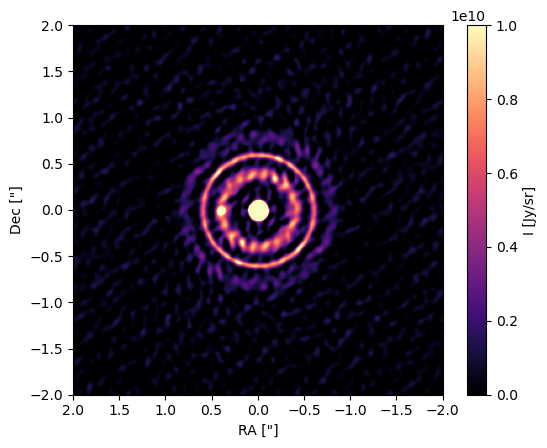

In [134]:
import matplotlib.colors as colors
norm = colors.PowerNorm(gamma = 1, vmin = 0, vmax = 1e10)

plt.imshow(
            I_syn, 
            extent=[frank2d.Rmax, -frank2d.Rmax, -frank2d.Rmax, frank2d.Rmax],
            norm=norm, 
            cmap = 'magma'
            )

plt.gca().invert_yaxis()
plt.xlim(rout, -rout)
plt.ylim(-rout, rout)
#plt.title('Synthetic model of a non axisymmetric disk')
plt.xlabel('RA ["]')
plt.ylabel('Dec ["]')
plt.colorbar(label='I [Jy/sr]')